In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns





In [63]:
df = pd.read_csv('/content/drive/MyDrive/Artificial_Intelligence/DataSet/kaggle_london_house_price_data.csv')
df.head()

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"1 Guinness Court, Mansell Street, London, E1 8AB",E1 8AB,England,E1,51.512982,-0.073698,1.0,2.0,79.0,NaN,...,666000.0,LOW,2024-10-07T13:26:59.894Z,-29445000.0,-98.150000,2020-03-27,2020-03-27,30000000,NaN,NaN
1,"306 Marlyn Lodge, 2 Portsoken Street, London, ...",E1 8RB,England,E1,51.511881,-0.073471,1.0,1.0,54.0,1.0,...,546000.0,MEDIUM,2024-10-07T13:26:59.894Z,46000.0,10.222222,2022-09-16,2022-09-16,450000,NaN,NaN
2,"Flat 1, White Rose Court, Widegate Street, Lon...",E1 7ES,England,E1,51.517972,-0.078028,2.0,2.0,73.0,1.0,...,684000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,4.494382,2023-10-31,2023-10-31,623000,3.833333,23000.0
3,"Flat 1, White Rose Court, Widegate Street, Lon...",E1 7ES,England,E1,51.517972,-0.078028,2.0,2.0,73.0,1.0,...,684000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,4.494382,2023-10-31,2016-03-23,600000,155.319149,365000.0
4,"Flat 1, White Rose Court, Widegate Street, Lon...",E1 7ES,England,E1,51.517972,-0.078028,2.0,2.0,73.0,1.0,...,684000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,4.494382,2023-10-31,2005-11-28,235000,181.437126,151500.0


Data Cleaning

In [4]:
df = df.dropna(subset=['history_numericChange','currentEnergyRating','bathrooms','saleEstimate_valueChange.numericChange'])

df = df.drop(columns=['fullAddress','country','saleEstimate_ingestedAt','postcode'], errors='ignore')

num_cols = [
    'bedrooms','floorAreaSqM','livingRooms',
    'rentEstimate_lowerPrice','rentEstimate_upperPrice','rentEstimate_currentPrice',
    'saleEstimate_lowerPrice','saleEstimate_upperPrice','saleEstimate_currentPrice'
]

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

Date Feature Engineering

In [5]:
if 'history_date' in df.columns:
    df['history_date'] = pd.to_datetime(df['history_date'])
    df['hist_year'] = df['history_date'].dt.year
    df = df.drop(columns=['history_date'])

if 'saleEstimate_valueChange.saleDate' in df.columns:
    df['saleEstimate_valueChange.saleDate'] = pd.to_datetime(df['saleEstimate_valueChange.saleDate'])
    df['sale_year'] = df['saleEstimate_valueChange.saleDate'].dt.year
    df = df.drop(columns=['saleEstimate_valueChange.saleDate'])

Encoding

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['currentEnergyRating'] = le.fit_transform(df['currentEnergyRating'])

Remove Data Leakage

In [7]:
leak_cols = [
    'saleEstimate_currentPrice',
    'saleEstimate_upperPrice',
    'saleEstimate_lowerPrice',
    'rentEstimate_currentPrice',
    'rentEstimate_upperPrice',
    'rentEstimate_lowerPrice'
]

for col in leak_cols:
    if col in df.columns:
        df = df.drop(columns=col)

Visualization

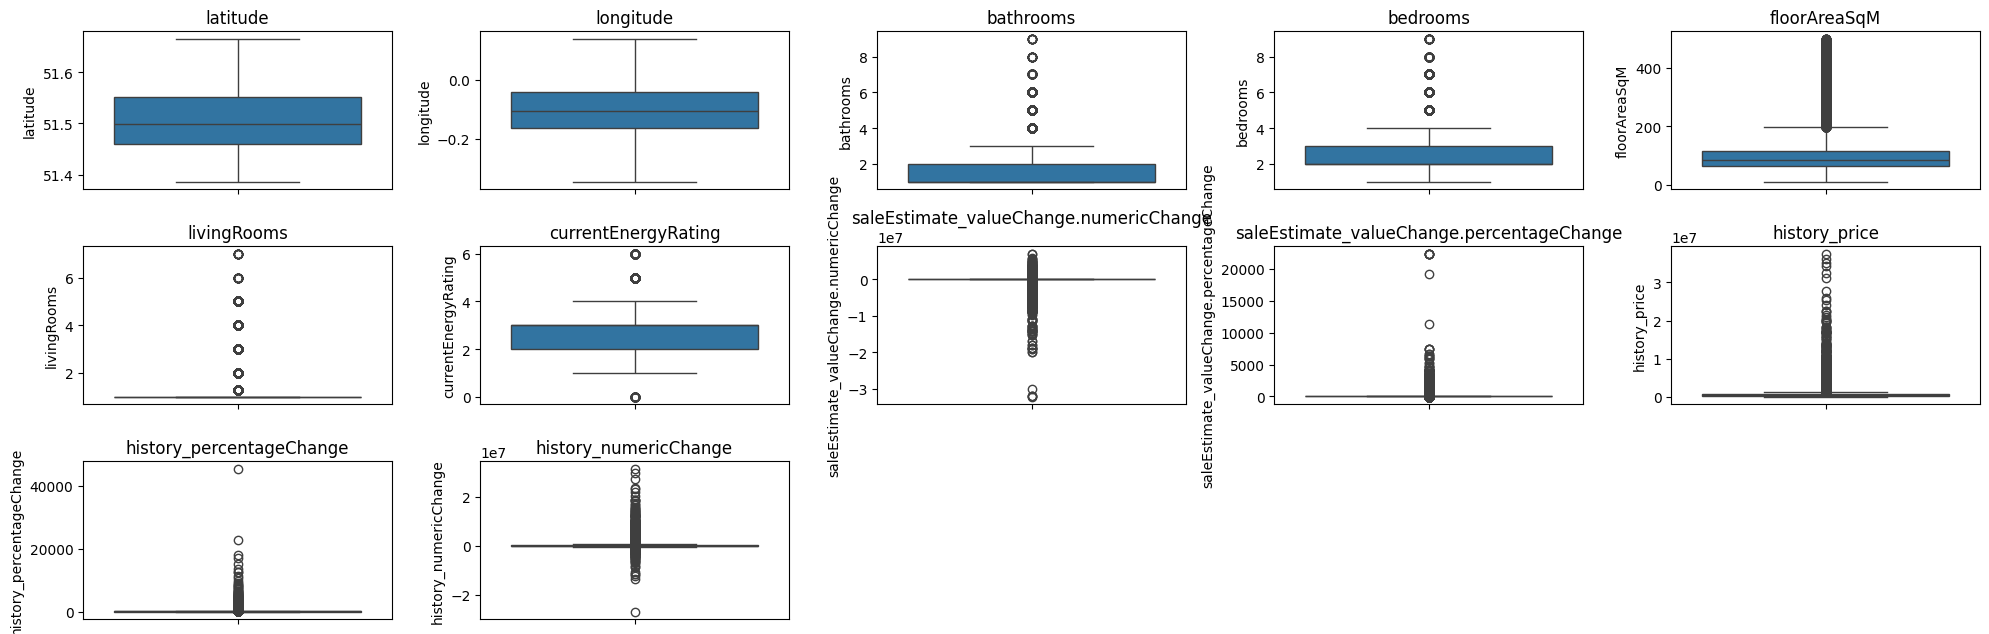

In [8]:
def show_box_plot(dataframe):
    numerical_features = dataframe.select_dtypes(include=['int64','float64'])
    plt.figure(figsize=(20,15))
    for i, col in enumerate(numerical_features,1):
        plt.subplot(7,5,i)
        sns.boxplot(y=dataframe[col])
        plt.title(col)
    plt.tight_layout()
    plt.show()

show_box_plot(df)

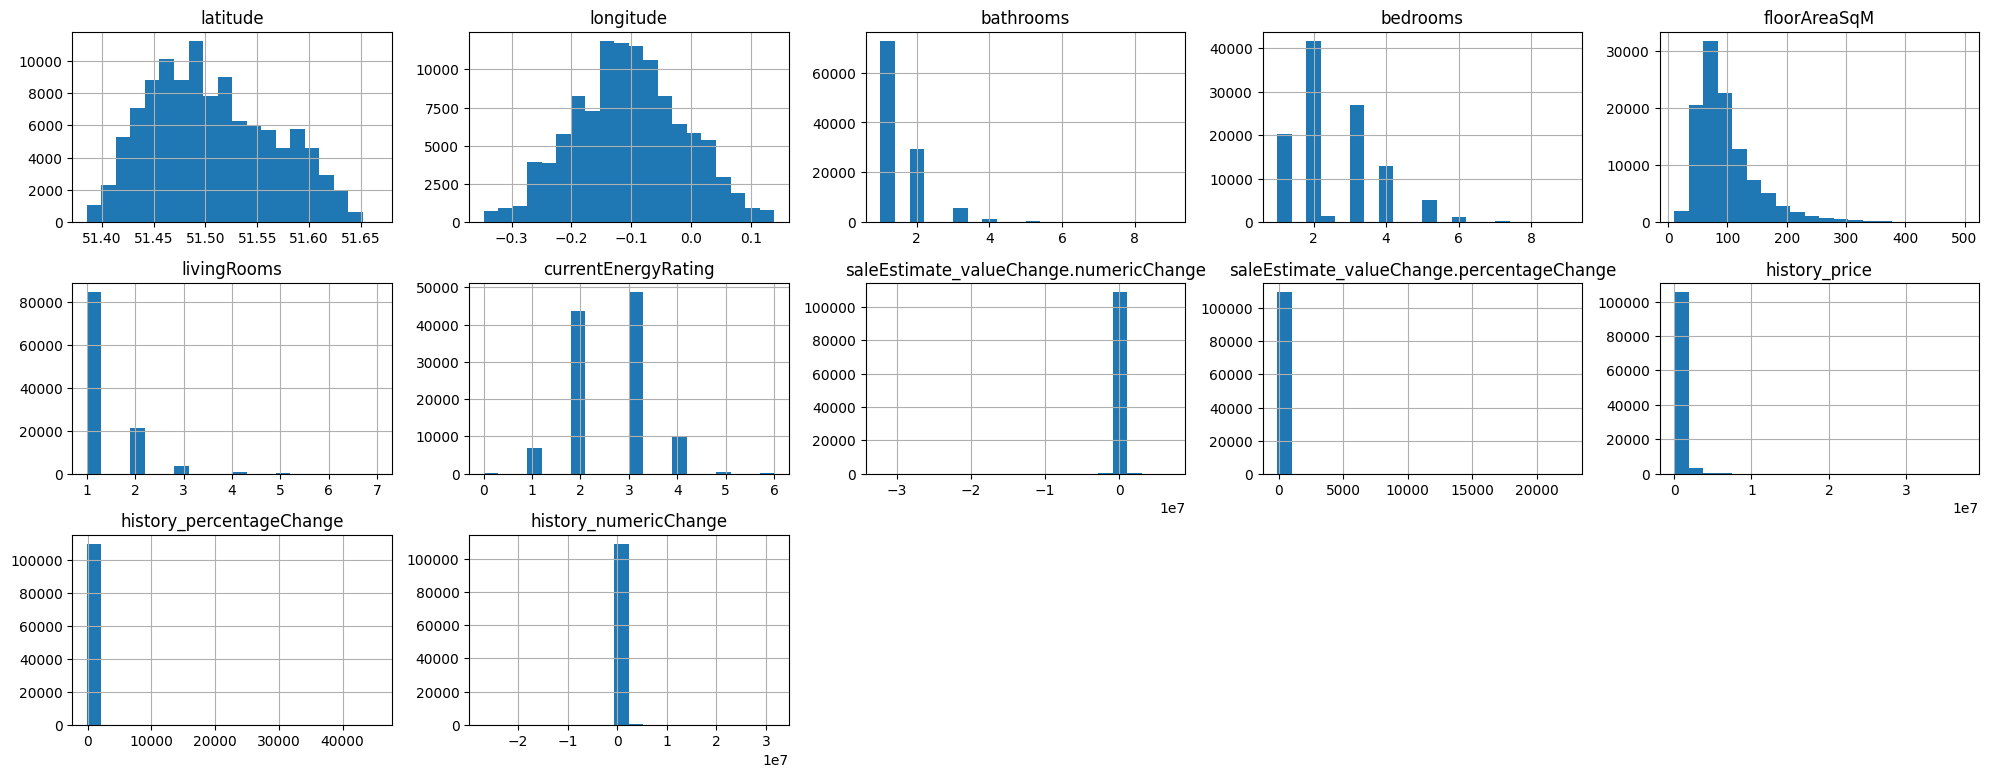

In [9]:
def show_hist(dataframe):
    numerical_features = dataframe.select_dtypes(include=['int64','float64']).columns
    plt.figure(figsize=(20,15))
    for i, feature in enumerate(numerical_features,1):
        plt.subplot(6,5,i)
        dataframe[feature].hist(bins=20)
        plt.title(feature)
    plt.tight_layout()
    plt.show()

show_hist(df)


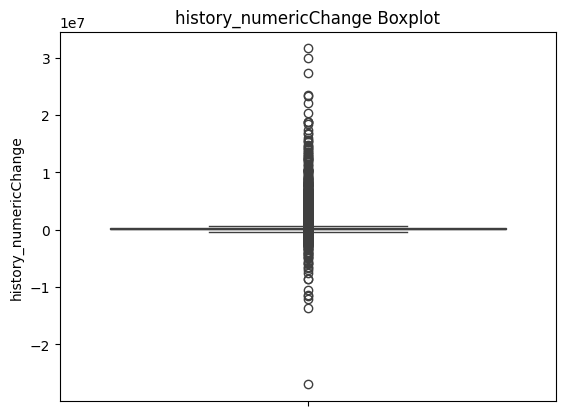

In [11]:
sns.boxplot(y=df['history_numericChange'])
plt.title("history_numericChange Boxplot")
plt.show()

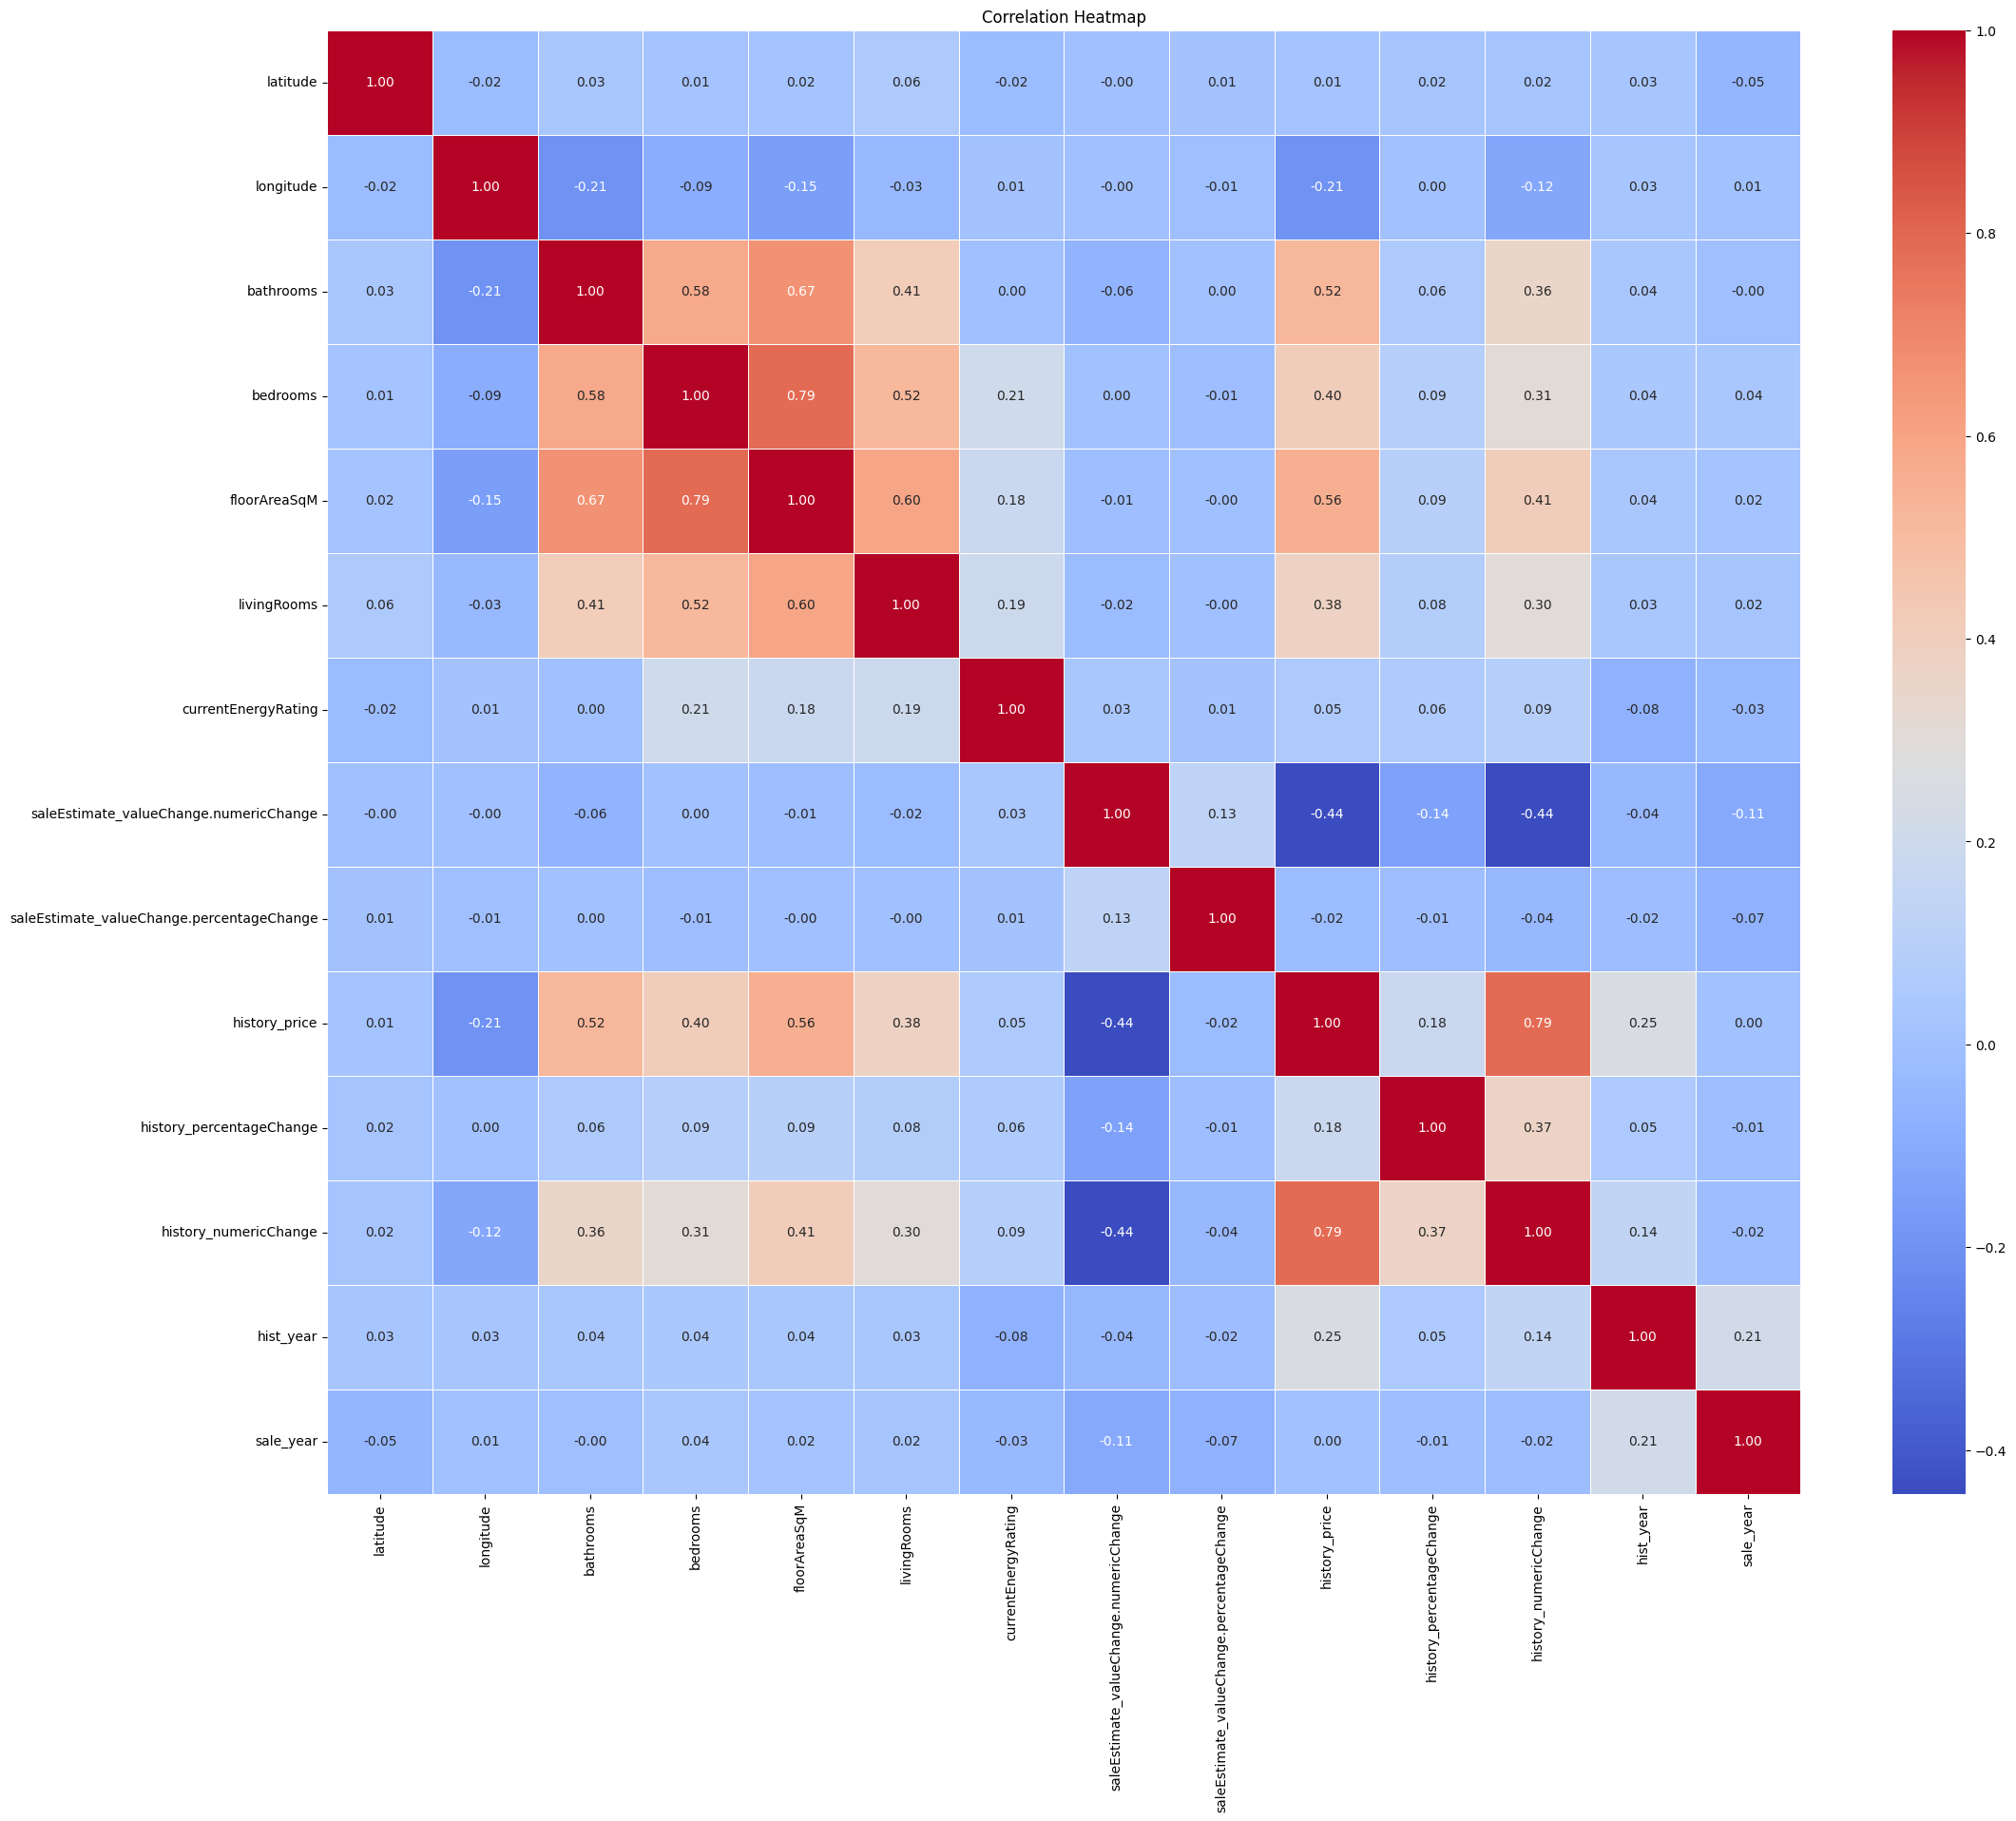

In [12]:
plt.figure(figsize=(25, 20))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

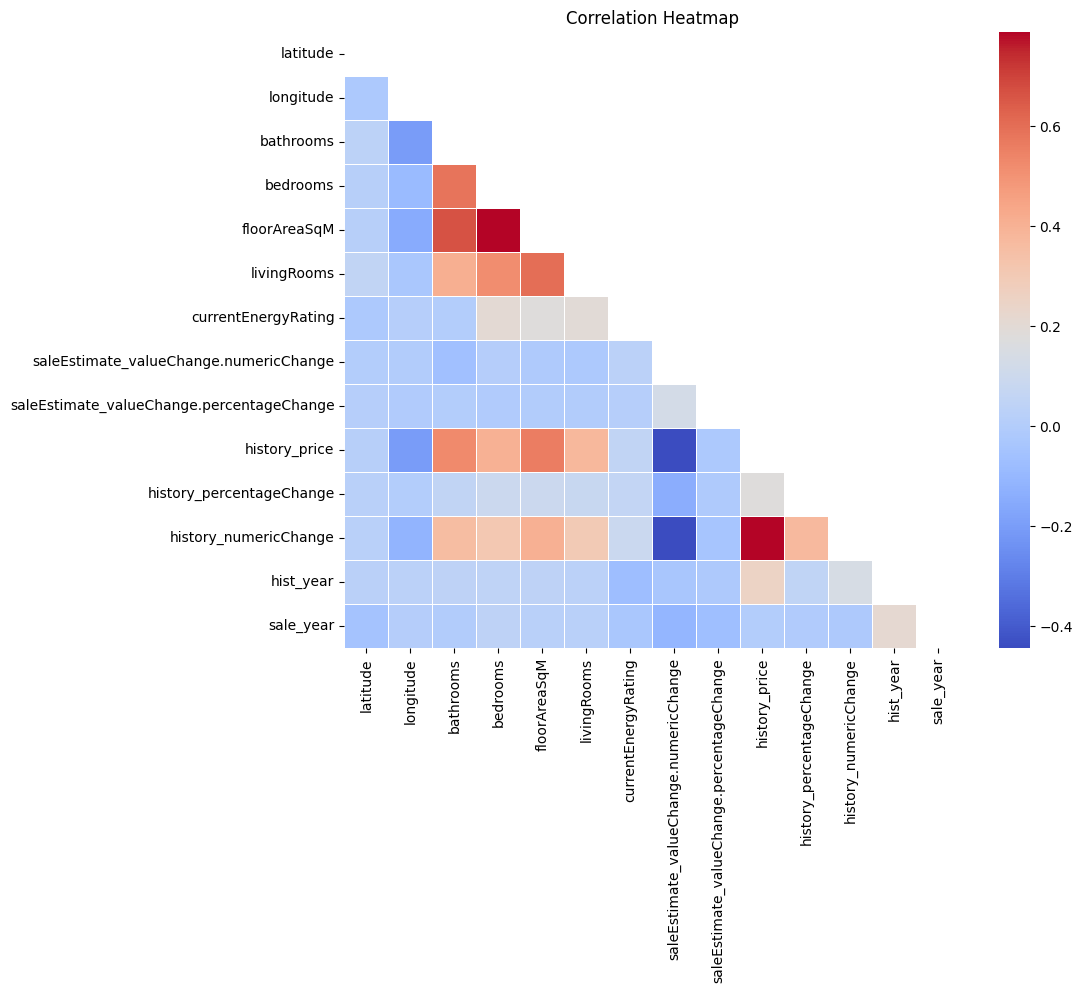

In [13]:
def show_corr_heatmap(df, title):
    corr = df.corr(numeric_only=True)
    mask = np.zeros_like(corr)
    mask[np.triu_indices_from(mask)] = True

    plt.figure(figsize = (10, 8))
    plt.title(title)
    sns.heatmap(corr, annot=False, linewidths=.5, square=True, mask=mask, cmap='coolwarm')
    plt.show()

show_corr_heatmap(df, 'Correlation Heatmap')

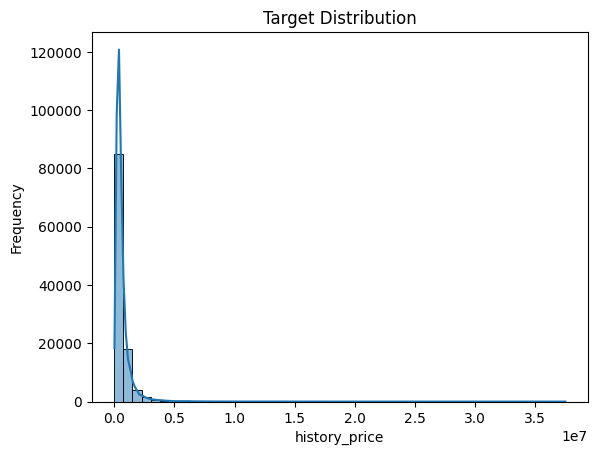

In [16]:
sns.histplot(df['history_price'], bins=50, kde=True)
plt.title("Target Distribution")
plt.xlabel("history_price")
plt.ylabel("Frequency")
plt.show()

Outlier Removal

In [17]:
def remove_outliers(df, column):
    upper = df[column].mean() + 3*df[column].std()
    lower = df[column].mean() - 3*df[column].std()
    return df[(df[column] < upper) & (df[column] > lower)]

for col in ['history_price','history_numericChange']:
    df = remove_outliers(df, col)

df = df[df['hist_year'] > 2010]

Split Features & Target

In [18]:
features = df.drop(columns=['history_price'])
target = df['history_price']

One-Hot Encoding

In [19]:
categorical_cols = [col for col in ['outcode','tenure','propertyType','saleEstimate_confidenceLevel'] if col in features.columns]

features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature Selection

In [22]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print(feature_scores.head(10))

                             Feature         Score
4                       floorAreaSqM  60576.624819
10             history_numericChange  35041.555058
2                          bathrooms  27450.438109
3                           bedrooms  26526.115061
177                  tenure_Freehold  10808.354310
178                 tenure_Leasehold  10567.988309
5                        livingRooms   9766.292187
1                          longitude   6170.090926
191  propertyType_Purpose Built Flat   5978.262621
189   propertyType_Mid Terrace House   2756.586547


Models

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

lin_model = LinearRegression().fit(X_train, y_train)

knn_model = KNeighborsRegressor(n_neighbors=5).fit(X_train_scaled, y_train)

tree_model = DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train, y_train)

gb_model = GradientBoostingRegressor().fit(X_train, y_train)

xgb_model = XGBRegressor().fit(X_train, y_train)

Hyperparameter Tuning

In [24]:
from sklearn.model_selection import RandomizedSearchCV

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

gb_random = RandomizedSearchCV(
    GradientBoostingRegressor(),
    gb_params,
    n_iter=3,
    cv=2,
    n_jobs=-1,
    random_state=42
)

gb_random.fit(X_train, y_train)

print("Best Params:", gb_random.best_params_)

gb_best = gb_random.best_estimator_
print("Tuned GB Test:", gb_best.score(X_test, y_test))

Best Params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Tuned GB Test: 0.952297992113267


Model Evaluation

In [25]:
print("LR:", lin_model.score(X_test, y_test))
print("KNN:", knn_model.score(X_test_scaled, y_test))
print("DT:", tree_model.score(X_test, y_test))
print("GB:", gb_model.score(X_test, y_test))
print("XGB:", xgb_model.score(X_test, y_test))

print("Overfitting Check (GB):", gb_model.score(X_train, y_train), gb_model.score(X_test, y_test))

LR: 0.7743669286491505
KNN: 0.7448290765105814
DT: 0.8311031231404287
GB: 0.9156557402634278
XGB: 0.9745978116989136
Overfitting Check (GB): 0.9235078558320219 0.9156557402634278


  Prediction Metrics

RMSE: 119918.03812365608
MAE: 72719.67458091253
R2: 0.9156557402634278


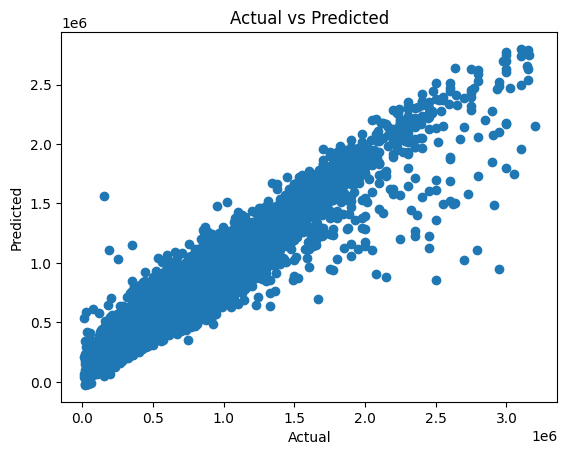

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

preds = gb_model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Feature Importance

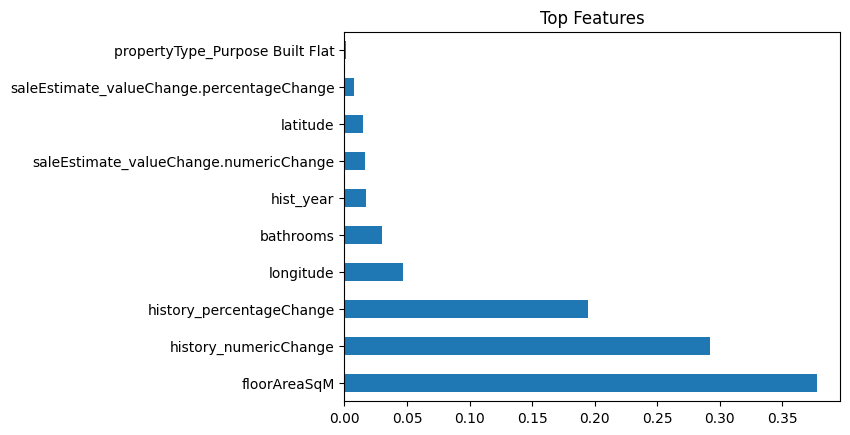

In [28]:
importances = pd.Series(gb_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

Apply ANN

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [56]:
nn_model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(32, activation='relu'),

    Dense(1)
])

In [57]:
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [58]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [59]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 330797645824.0000 - mae: 440289.8750 - val_loss: 72704122880.0000 - val_mae: 178669.8594
Epoch 2/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 61720227840.0000 - mae: 159665.0156 - val_loss: 45979918336.0000 - val_mae: 129817.3594
Epoch 3/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 52370575360.0000 - mae: 145524.0781 - val_loss: 41258991616.0000 - val_mae: 122564.3750
Epoch 4/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 49330954240.0000 - mae: 141846.1406 - val_loss: 39782207488.0000 - val_mae: 118390.9531
Epoch 5/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 47549775872.0000 - mae: 139110.2656 - val_loss: 37586374656.0000 - val_mae: 116043.2109
Epoch 6/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 46591496192.0000 - mae: 137171.0938 - val_loss: 36837654528.0000 - val_mae: 114206.2891
Epoch 7/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 45257060352.0000 - mae: 136046.4219 - val_loss: 358

476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25061302272.0000 - mae: 93260.6172
Test Loss: 25061302272.0
Test MAE: 93260.6171875


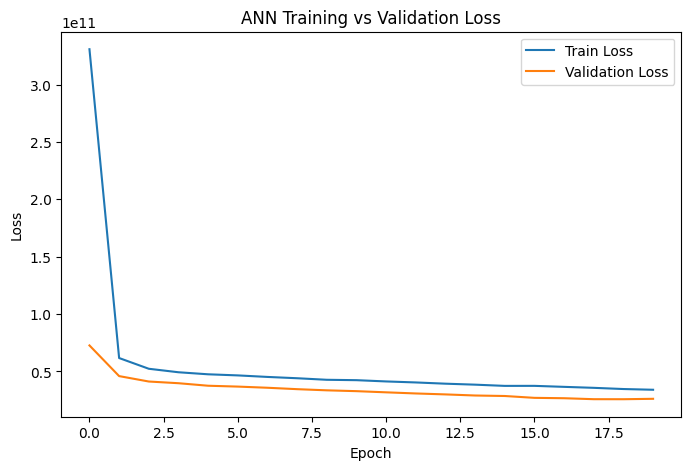

In [60]:
loss, mae = nn_model.evaluate(X_test_scaled, y_test)
print("Test Loss:", loss)
print("Test MAE:", mae)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training vs Validation Loss")
plt.legend()
plt.show()

Model Comparison Graph

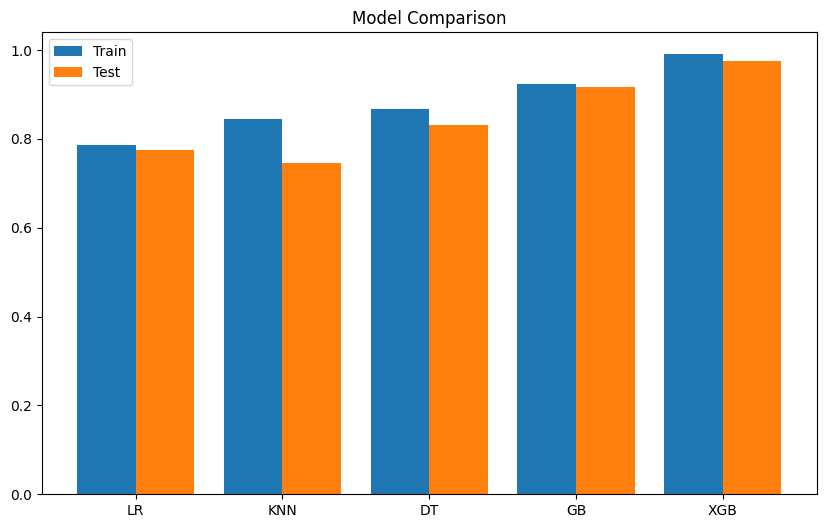

In [61]:
models = ['LR','KNN','DT','GB','XGB']

train_scores = [
    lin_model.score(X_train, y_train),
    knn_model.score(X_train_scaled, y_train),
    tree_model.score(X_train, y_train),
    gb_model.score(X_train, y_train),
    xgb_model.score(X_train, y_train)
]

test_scores = [
    lin_model.score(X_test, y_test),
    knn_model.score(X_test_scaled, y_test),
    tree_model.score(X_test, y_test),
    gb_model.score(X_test, y_test),
    xgb_model.score(X_test, y_test)
]

x = np.arange(len(models))

plt.figure(figsize=(10,6))
plt.bar(x-0.2, train_scores, width=0.4, label='Train')
plt.bar(x+0.2, test_scores, width=0.4, label='Test')
plt.xticks(x, models)
plt.legend()
plt.title("Model Comparison")
plt.show()